# Entraînement CNN — Reconnaissance de kana (hiragana + katakana)

96 classes (48 hiragana + 48 katakana), dataset généré à partir de polices japonaises.

## 1. Imports & configuration

In [ ]:
import json
import os
import random
from pathlib import Path

import numpy as np
import scipy.ndimage as ndi
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import confusion_matrix, classification_report

# Police japonaise pour matplotlib (macOS)
matplotlib.rcParams["font.family"] = "Hiragino Sans"

# Seeds fixes pour reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Config
DATA_DIR = Path("data")
MODELS_DIR = Path("models")
PLOTS_DIR = Path("plots")
MODELS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

NUM_CLASSES = 96
IMG_SIZE = 28
BATCH_SIZE = 64
EPOCHS = 100

print(f"TensorFlow {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

## 2. Chargement des données

In [2]:
# Charger le dataset et les labels
dataset = np.load(DATA_DIR / "kana_dataset.npz")
images = dataset["images"]  # (N, 28, 28) uint8
labels = dataset["labels"]  # (N,) uint8

with open(DATA_DIR / "labels.json") as f:
    label_info = json.load(f)

# Charger les indices de split
splits = np.load(DATA_DIR / "split_indices.npz")
train_idx = splits["train_idx"]
val_idx = splits["val_idx"]
test_idx = splits["test_idx"]

print(f"Dataset total : {len(images)} images, {len(np.unique(labels))} classes")
print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

Dataset total : 31200 images, 96 classes
Train: 21840 | Val: 4680 | Test: 4680


## 3. Preprocessing & split

X_train: (21840, 28, 28, 1) | X_val: (4680, 28, 28, 1) | X_test: (4680, 28, 28, 1)
Pixel range: [0.00, 1.00]


/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2271487757.py:24: UserWarning: Glyph 12396 (\N{HIRAGANA LETTER NU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2271487757.py:24: UserWarning: Glyph 12432 (\N{HIRAGANA LETTER WI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2271487757.py:24: UserWarning: Glyph 12528 (\N{KATAKANA LETTER WI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2271487757.py:24: UserWarning: Glyph 12425 (\N{HIRAGANA LETTER RA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2271487757.py:24: UserWarning: Glyph 12520 (\N{KATAKANA LETTER YO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2271487757.py:24: UserWar

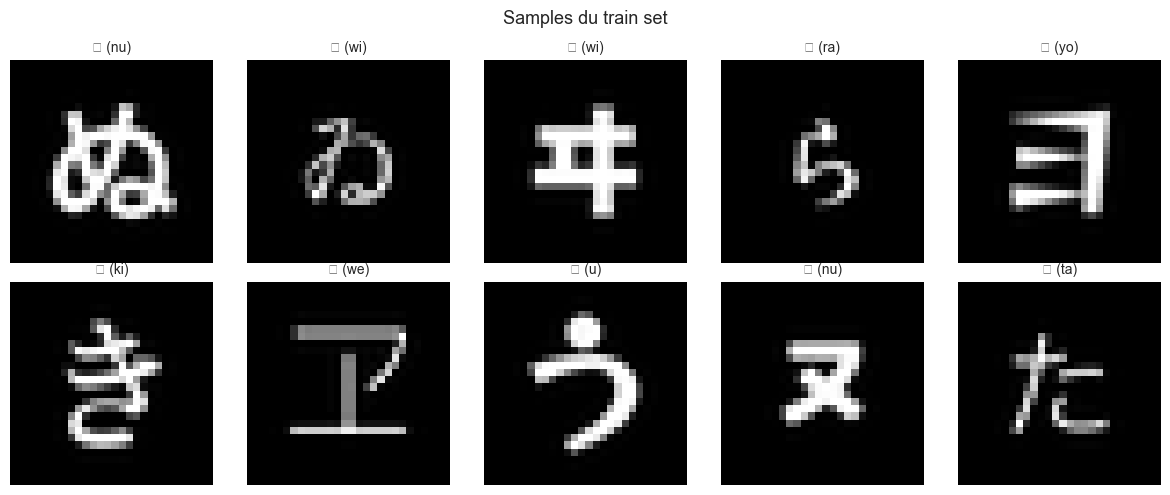

In [3]:
# Normaliser [0, 255] → [0, 1] et ajouter la dimension channel
X = images.astype(np.float32) / 255.0
X = X[..., np.newaxis]  # (N, 28, 28, 1)
y = labels.astype(np.int32)

# Split
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"X_train: {X_train.shape} | X_val: {X_val.shape} | X_test: {X_test.shape}")
print(f"Pixel range: [{X_train.min():.2f}, {X_train.max():.2f}]")

# Aperçu : 10 samples aléatoires du train set
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_train), 10, replace=False)
for ax, idx in zip(axes.flat, sample_idx):
    ax.imshow(X_train[idx, :, :, 0], cmap="gray")
    info = label_info[y_train[idx]]
    ax.set_title(f"{info['kana']} ({info['romaji']})", fontsize=10)
    ax.axis("off")
plt.suptitle("Samples du train set", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Data augmentation (on the fly)

/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/1461035676.py:91: UserWarning: Glyph 12504 (\N{KATAKANA LETTER HE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/1461035676.py:91: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/1461035676.py:91: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) Arial.
  plt.tight_layout()


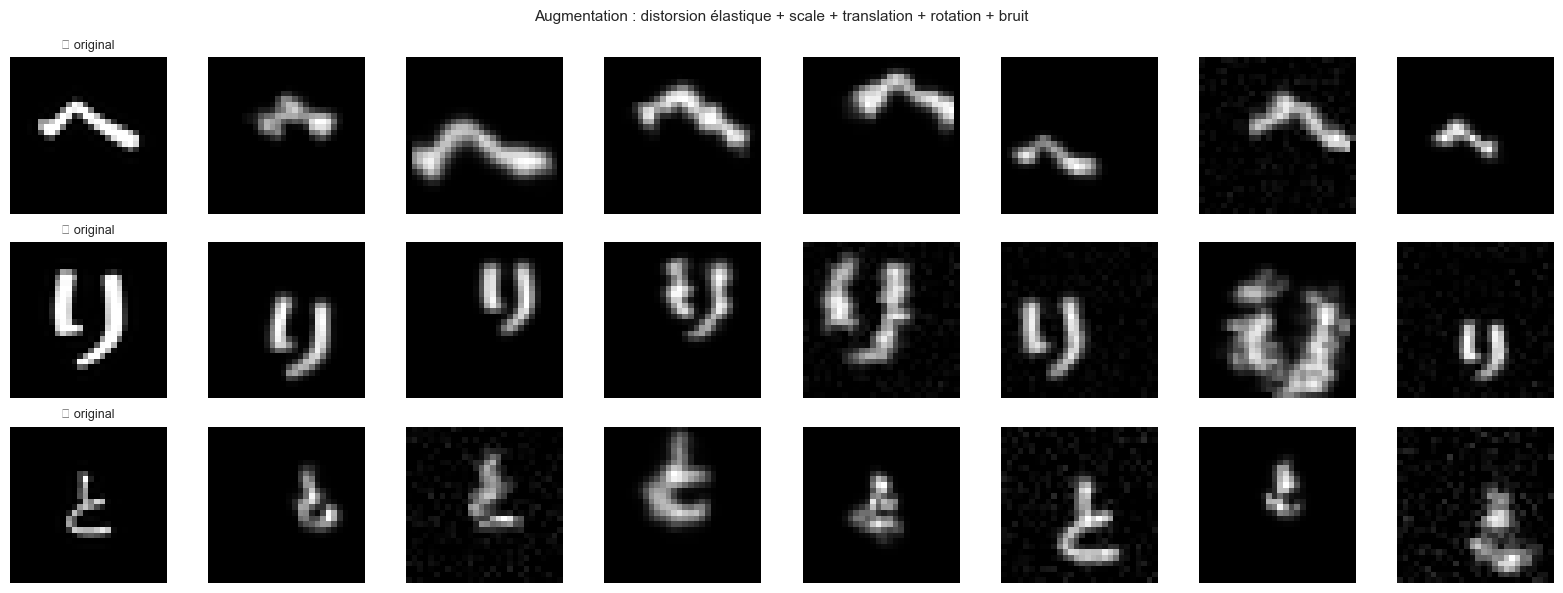

In [19]:
def elastic_distortion(image, alpha=3.0, sigma=0.7):
    """Distorsion élastique non-linéaire continue (Simard et al. 2003)."""
    shape = image.shape[:2]
    dx = ndi.gaussian_filter(np.random.randn(*shape), sigma) * alpha
    dy = ndi.gaussian_filter(np.random.randn(*shape), sigma) * alpha

    y, x = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]), indexing="ij")
    coords = [np.clip(y + dy, 0, shape[0] - 1), np.clip(x + dx, 0, shape[1] - 1)]
    return ndi.map_coordinates(image, coords, order=1, mode="constant").astype(np.float32)


def pad_or_crop(img, size=28):
    """Force une image à exactement size×size."""
    h, w = img.shape[:2]
    if h > size:
        s = (h - size) // 2
        img = img[s:s + size, :]
    if w > size:
        s = (w - size) // 2
        img = img[:, s:s + size]
    h, w = img.shape[:2]
    if h < size or w < size:
        ph = (size - h + 1) // 2
        pw = (size - w + 1) // 2
        img = np.pad(img, ((ph, size - h - ph), (pw, size - w - pw)), mode="constant")
    return img


def augment_batch(images, labels):
    """Augmentation on the fly.

    Priorités :
    - BEAUCOUP de déformations élastiques (non-linéaires, continues)
    - BEAUCOUP de scale up/down + translation
    - Rotation modérée (±8°)
    - Un peu de bruit léger
    - PAS d'érosion/dilatation (préserve le contraste)
    """
    batch_size = len(images)
    augmented = np.empty_like(images)

    for i in range(batch_size):
        img = images[i, :, :, 0].copy()

        # 1. Distorsion élastique (90% de chance, paramètres doux)
        if np.random.random() < 0.9:
            alpha = np.random.uniform(2.0, 4.5)
            sigma = np.random.uniform(0.5, 0.9)
            img = elastic_distortion(img, alpha=alpha, sigma=sigma)

        # 2. Scale (zoom in/out) — large range
        zoom_factor = np.random.uniform(0.6, 1.4)
        img = ndi.zoom(img, zoom_factor, order=1, mode="constant")
        img = pad_or_crop(img, 28)

        # 3. Translation — large range
        shift_y = np.random.uniform(-0.20, 0.20) * 28
        shift_x = np.random.uniform(-0.20, 0.20) * 28
        img = ndi.shift(img, [shift_y, shift_x], order=1, mode="constant")

        # 4. Rotation modérée
        angle = np.random.uniform(-8, 8)
        img = ndi.rotate(img, angle, reshape=False, order=1, mode="constant")

        # 5. Bruit léger (40% de chance, faible amplitude)
        if np.random.random() < 0.4:
            noise = np.random.normal(0, np.random.uniform(0.01, 0.04), img.shape)
            img = np.clip(img + noise, 0, 1)

        augmented[i, :, :, 0] = img

    return augmented, labels


# --- Aperçu ---
fig, axes = plt.subplots(3, 8, figsize=(16, 6))

for row in range(3):
    sample = X_train[row * 100: row * 100 + 1]
    info = label_info[y_train[row * 100]]
    axes[row, 0].imshow(sample[0, :, :, 0], cmap="gray")
    axes[row, 0].set_title(f"{info['kana']} original", fontsize=9)
    axes[row, 0].axis("off")

    for col in range(1, 8):
        aug, _ = augment_batch(sample, None)
        axes[row, col].imshow(aug[0, :, :, 0], cmap="gray")
        axes[row, col].axis("off")

plt.suptitle("Augmentation : distorsion élastique + scale + translation + rotation + bruit", fontsize=11)
plt.tight_layout()
plt.show()

## 5. Architecture du modèle

In [5]:
def build_model():
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

    # PAS d'augmentation dans le modèle — elle est appliquée via le générateur custom

    # Block 1
    x = layers.Conv2D(32, 3, padding="same")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 2
    x = layers.Conv2D(64, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # Block 3
    x = layers.Conv2D(128, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Classifier
    x = layers.Dense(256)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="kana_cnn")
    return model

model = build_model()
model.summary()

Model: "kana_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 96)             │        24,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 152,288 (594.88 KB)

 Trainable params: 151,328 (591.12 KB)

 Non-trainable params: 960 (3.75 KB)

## 6. Compilation & callbacks

In [6]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        patience=4,
        factor=0.5,
        min_lr=1e-6,
        verbose=1,
    ),
    keras.callbacks.ModelCheckpoint(
        str(MODELS_DIR / "best_model.keras"),
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1,
    ),
]

print("Modèle compilé.")

Modèle compilé.


## 7. Entraînement

In [7]:
# Générateur custom qui applique l'augmentation agressive on the fly
def train_generator(X, y, batch_size):
    """Générateur infini de batches augmentés."""
    n = len(X)
    indices = np.arange(n)
    while True:
        np.random.shuffle(indices)
        for start in range(0, n, batch_size):
            batch_idx = indices[start:start + batch_size]
            batch_x, batch_y = X[batch_idx], y[batch_idx]
            batch_x_aug, _ = augment_batch(batch_x, batch_y)
            yield batch_x_aug, batch_y

train_gen = train_generator(X_train, y_train, BATCH_SIZE)
steps_per_epoch = len(X_train) // BATCH_SIZE

history = model.fit(
    train_gen,
    steps_per_epoch=steps_per_epoch,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/100
340/341 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.0182 - loss: 4.7847
Epoch 1: val_accuracy improved from None to 0.01111, saving model to models/best_model.keras

Epoch 1: finished saving model to models/best_model.keras
341/341 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.0261 - loss: 4.6225 - val_accuracy: 0.0111 - val_loss: 4.6952 - learning_rate: 0.0010
Epoch 2/100
341/341 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.0817 - loss: 3.9797
Epoch 2: val_accuracy improved from 0.01111 to 0.30705, saving model to models/best_model.keras

Epoch 2: finished saving model to models/best_model.keras
341/341 ━━━━━━━━━━━━━━━━━━━━ 10s 29ms/step - accuracy: 0.1114 - loss: 3.7510 - val_accuracy: 0.3071 - val_loss: 2.4823 - learning_rate: 0.0010
Epoch 3/100
340/341 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.1991 - loss: 3.2052
Epoch 3: val_accuracy improved from 0.30705 to 0.44915, saving model to models/best_model.keras

Epoch 3: finished saving model to models/best_

## 8. Courbes d'entraînement

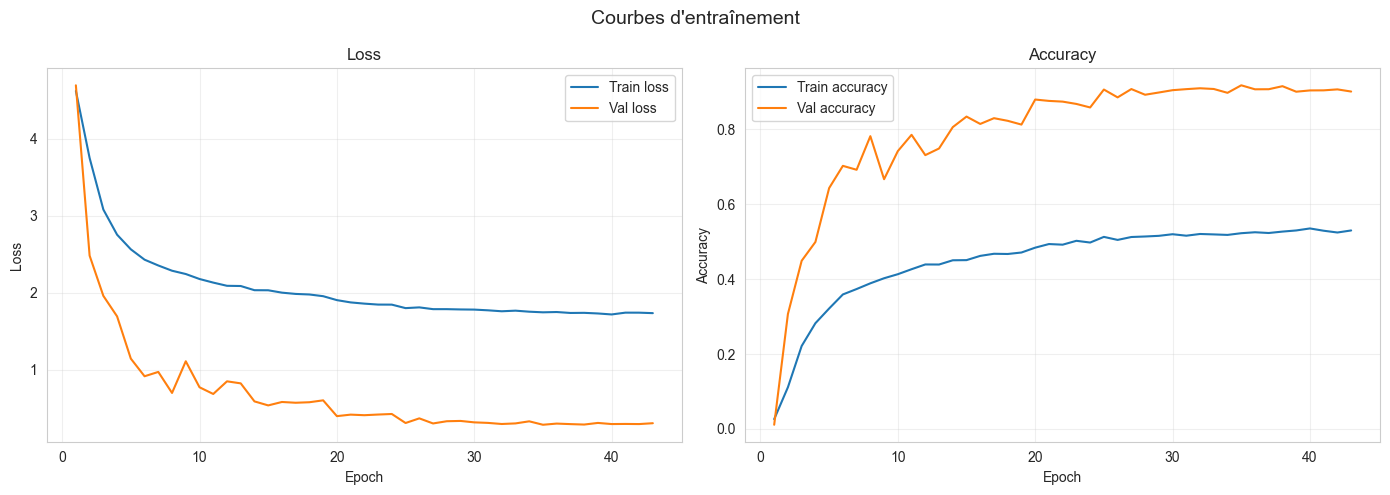


Train acc: 0.5302 | Val acc: 0.9013 | Gap: 37.1%
⚠️  Gap train/val > 10% — risque d'overfitting


In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history.history["loss"]) + 1)

# Loss
ax1.plot(epochs_range, history.history["loss"], label="Train loss")
ax1.plot(epochs_range, history.history["val_loss"], label="Val loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history.history["accuracy"], label="Train accuracy")
ax2.plot(epochs_range, history.history["val_accuracy"], label="Val accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Courbes d'entraînement", fontsize=14)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Gap train/val
final_train_acc = history.history["accuracy"][-1]
final_val_acc = history.history["val_accuracy"][-1]
gap = abs(final_train_acc - final_val_acc) * 100
print(f"\nTrain acc: {final_train_acc:.4f} | Val acc: {final_val_acc:.4f} | Gap: {gap:.1f}%")
if gap > 10:
    print("⚠️  Gap train/val > 10% — risque d'overfitting")

## 9. Évaluation sur le test set

In [9]:
# Évaluation globale
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# Top-5 accuracy
y_pred_proba = model.predict(X_test, verbose=0)
top5 = np.mean([y_test[i] in np.argsort(y_pred_proba[i])[-5:] for i in range(len(y_test))])
print(f"Top-5 accuracy: {top5:.4f}")

# Accuracy par type
y_pred = np.argmax(y_pred_proba, axis=1)
hira_mask = y_test < 48
kata_mask = y_test >= 48
hira_acc = np.mean(y_pred[hira_mask] == y_test[hira_mask])
kata_acc = np.mean(y_pred[kata_mask] == y_test[kata_mask])
print(f"\nHiragana accuracy: {hira_acc:.4f}")
print(f"Katakana accuracy: {kata_acc:.4f}")

Test loss: 0.2741
Test accuracy: 0.9184
Top-5 accuracy: 0.9929

Hiragana accuracy: 0.9047
Katakana accuracy: 0.9321


## 10. Matrice de confusion

/Users/aelbourachdi/PycharmProjects/japanese-flash-card/.venv1/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12354 (\N{HIRAGANA LETTER A}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/aelbourachdi/PycharmProjects/japanese-flash-card/.venv1/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/aelbourachdi/PycharmProjects/japanese-flash-card/.venv1/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12358 (\N{HIRAGANA LETTER U}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/aelbourachdi/PycharmProjects/japanese-flash-card/.venv1/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12360 (\N{HIRAGANA LETTER E}) missing from font(s) Arial.
  fig.canvas.draw()
/Users/aelbourachdi/PycharmProjects/japanese-flash-card/.venv1/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 12362 (\N{HIRAGANA LETTER O}

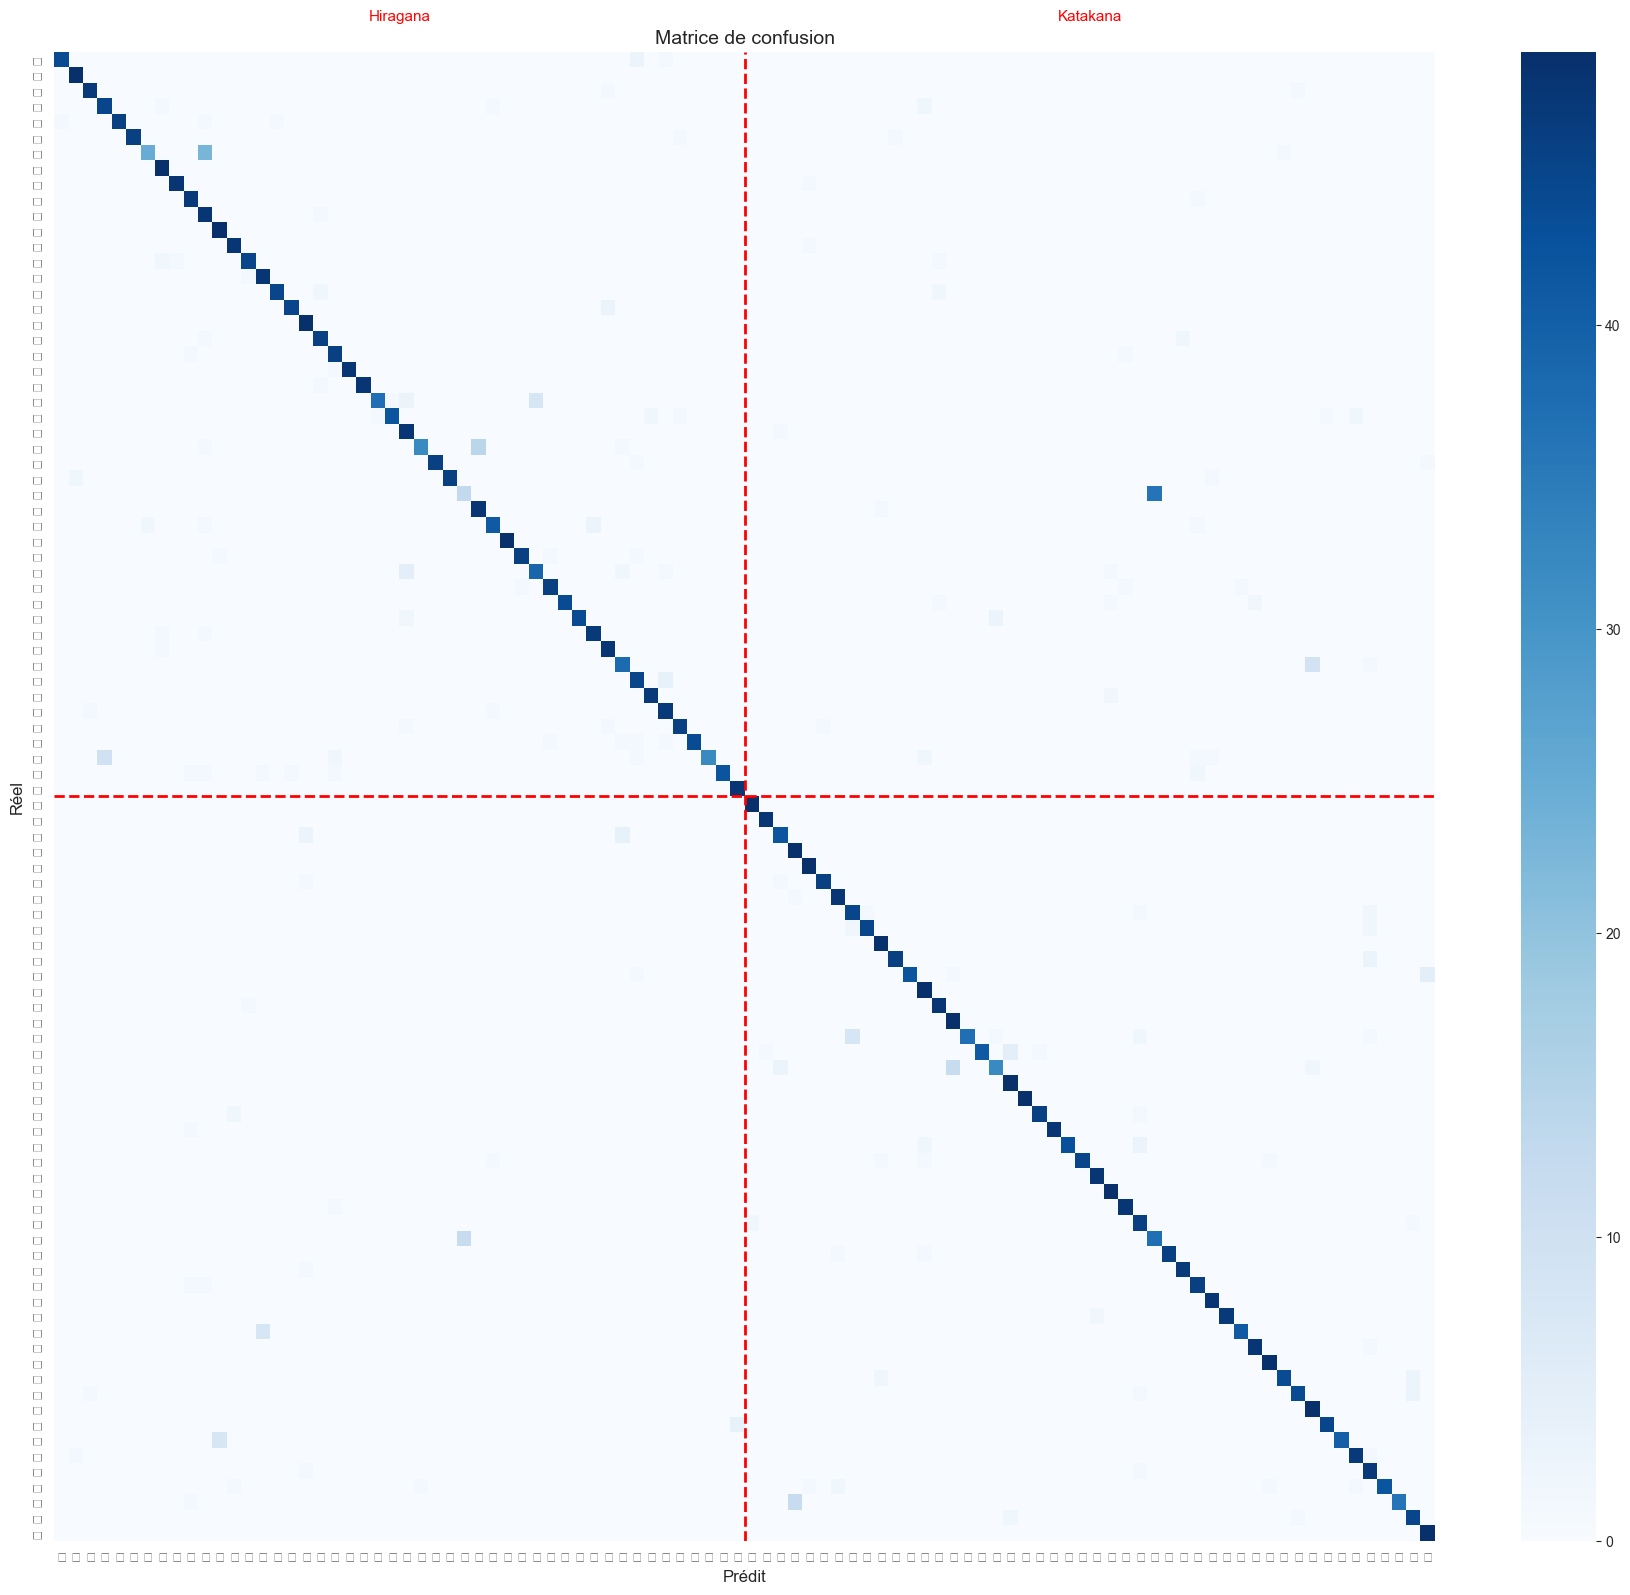

In [10]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(cm, ax=ax, cmap="Blues", fmt="d",
            xticklabels=[label_info[i]["kana"] for i in range(NUM_CLASSES)],
            yticklabels=[label_info[i]["kana"] for i in range(NUM_CLASSES)])
ax.set_xlabel("Prédit", fontsize=12)
ax.set_ylabel("Réel", fontsize=12)
ax.set_title("Matrice de confusion", fontsize=14)

# Ligne séparatrice hiragana / katakana
ax.axhline(y=48, color="red", linewidth=2, linestyle="--")
ax.axvline(x=48, color="red", linewidth=2, linestyle="--")
ax.text(24, -2, "Hiragana", ha="center", fontsize=11, color="red")
ax.text(72, -2, "Katakana", ha="center", fontsize=11, color="red")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Top 10 classes les plus difficiles

/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/367807639.py:29: UserWarning: Glyph 12426 (\N{HIRAGANA LETTER RI}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/367807639.py:29: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/367807639.py:29: UserWarning: Glyph 12504 (\N{KATAKANA LETTER HE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/367807639.py:29: UserWarning: Glyph 12396 (\N{HIRAGANA LETTER NU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/367807639.py:29: UserWarning: Glyph 12529 (\N{KATAKANA LETTER WE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/367807639.py:29: UserWarning: 

Top 10 classes les plus difficiles (recall le plus bas) :

 Idx  Kana  Romaji    Type          Recall
--------------------------------------------
  28     へ  he        hiragana      26.53%
   6     き  ki        hiragana      51.02%
  45     ゑ  we        hiragana      65.31%
  65     ツ  tsu       katakana      65.31%
  25     は  ha        hiragana      66.67%
  93     ヱ  we        katakana      73.47%
  22     ぬ  nu        hiragana      75.51%
  76     ヘ  he        katakana      75.51%
  63     タ  ta        katakana      75.51%
  39     り  ri        hiragana      79.17%


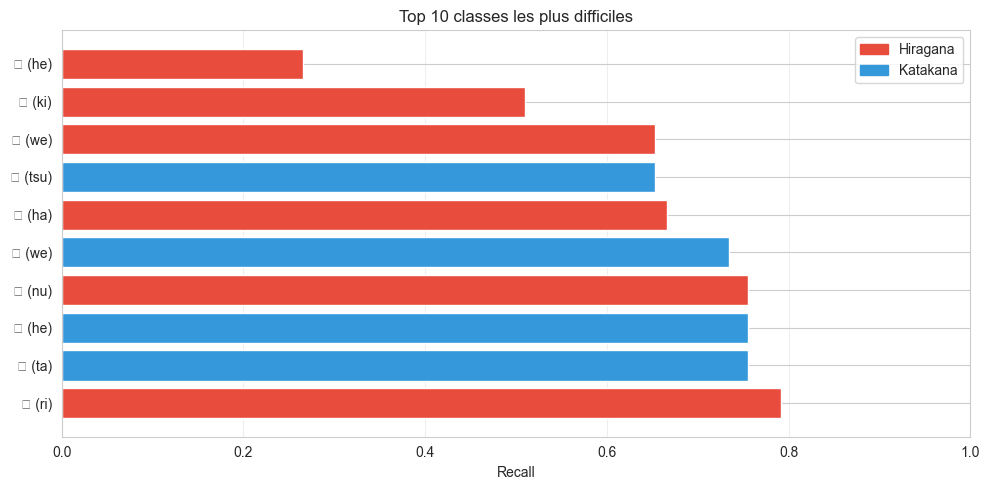

In [11]:
# Recall par classe
per_class_recall = cm.diagonal() / cm.sum(axis=1).clip(min=1)

# Top 10 pires
worst_idx = np.argsort(per_class_recall)[:10]

print("Top 10 classes les plus difficiles (recall le plus bas) :\n")
print(f"{'Idx':>4s}  {'Kana':>4s}  {'Romaji':<8s}  {'Type':<10s}  {'Recall':>8s}")
print("-" * 44)
for idx in worst_idx:
    info = label_info[idx]
    print(f"{idx:4d}  {info['kana']:>4s}  {info['romaji']:<8s}  {info['type']:<10s}  {per_class_recall[idx]:8.2%}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 5))
bar_labels = [f"{label_info[i]['kana']} ({label_info[i]['romaji']})" for i in worst_idx]
bar_values = [per_class_recall[i] for i in worst_idx]
colors = ["#e74c3c" if label_info[i]["type"] == "hiragana" else "#3498db" for i in worst_idx]
ax.barh(bar_labels[::-1], bar_values[::-1], color=colors[::-1])
ax.set_xlabel("Recall")
ax.set_title("Top 10 classes les plus difficiles")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.3, axis="x")

# Légende
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#e74c3c", label="Hiragana"), Patch(color="#3498db", label="Katakana")])

plt.tight_layout()
plt.savefig(PLOTS_DIR / "hardest_classes.png", dpi=150, bbox_inches="tight")
plt.show()

## 12. Exemples d'erreurs

/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2319704591.py:19: UserWarning: Glyph 12490 (\N{KATAKANA LETTER NA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2319704591.py:19: UserWarning: Glyph 12377 (\N{HIRAGANA LETTER SU}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2319704591.py:19: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2319704591.py:19: UserWarning: Glyph 12373 (\N{HIRAGANA LETTER SA}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2319704591.py:19: UserWarning: Glyph 12408 (\N{HIRAGANA LETTER HE}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/lt/5k6d3wd91vl0zm5q3frfn1bw0000gn/T/ipykernel_57234/2319704591.py:19: UserWar

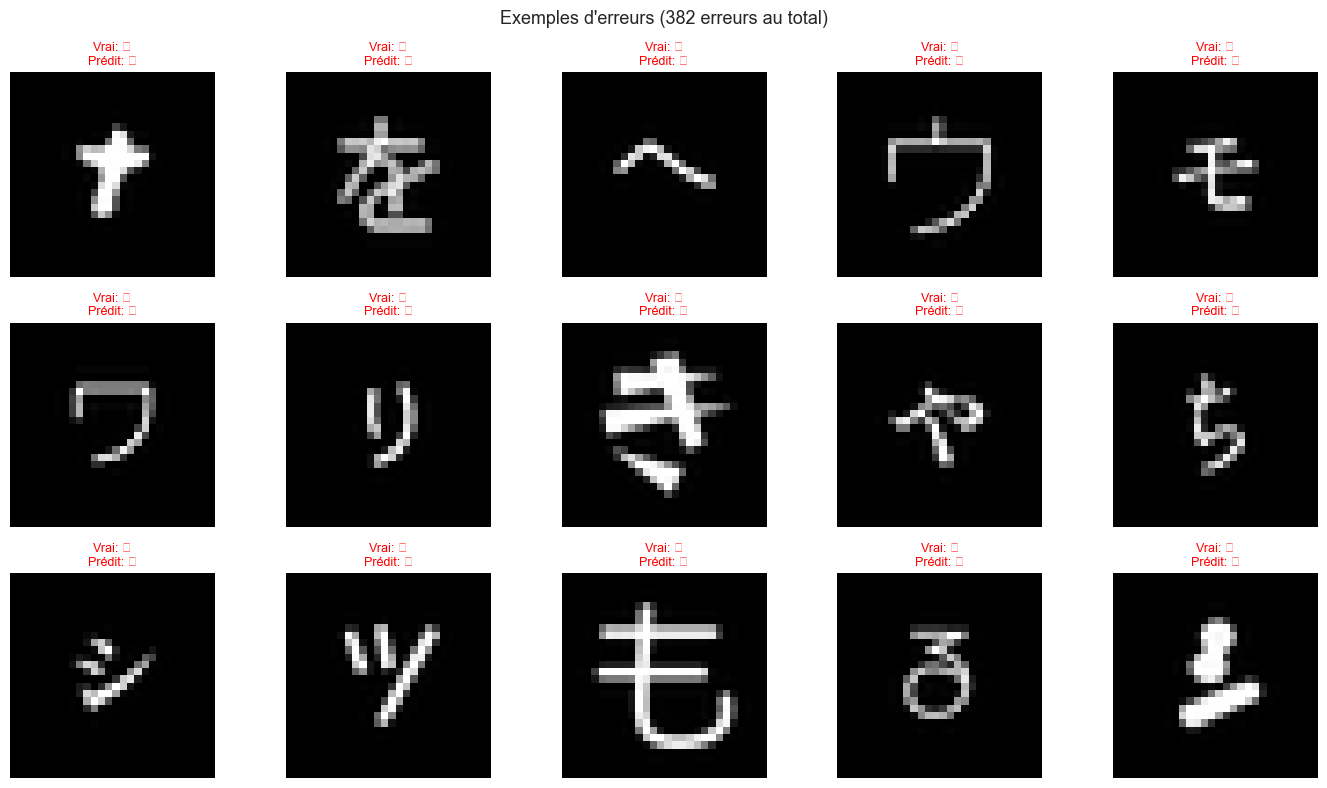

In [12]:
# Afficher des samples mal classés
errors = np.where(y_pred != y_test)[0]
n_show = min(15, len(errors))

if n_show == 0:
    print("Aucune erreur sur le test set !")
else:
    fig, axes = plt.subplots(3, 5, figsize=(14, 8))
    for ax, idx in zip(axes.flat, errors[:n_show]):
        ax.imshow(X_test[idx, :, :, 0], cmap="gray")
        true_info = label_info[y_test[idx]]
        pred_info = label_info[y_pred[idx]]
        ax.set_title(f"Vrai: {true_info['kana']}\nPrédit: {pred_info['kana']}", fontsize=9, color="red")
        ax.axis("off")
    # Masquer les axes vides
    for ax in axes.flat[n_show:]:
        ax.axis("off")
    plt.suptitle(f"Exemples d'erreurs ({len(errors)} erreurs au total)", fontsize=13)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "error_samples.png", dpi=150, bbox_inches="tight")
    plt.show()

## 13. Sauvegarde du modèle

In [13]:
# Le meilleur modèle est déjà sauvé via ModelCheckpoint
# On sauvegarde aussi le modèle final
model.save(str(MODELS_DIR / "final_model.keras"))

print(f"Modèles sauvegardés dans {MODELS_DIR}/")
print(f"  best_model.keras  — meilleure val_accuracy pendant l'entraînement")
print(f"  final_model.keras — état final après EarlyStopping")
print(f"\nPlots sauvegardés dans {PLOTS_DIR}/")
print(f"  training_curves.png")
print(f"  confusion_matrix.png")
print(f"  hardest_classes.png")
print(f"  error_samples.png")

Modèles sauvegardés dans models/
  best_model.keras  — meilleure val_accuracy pendant l'entraînement
  final_model.keras — état final après EarlyStopping

Plots sauvegardés dans plots/
  training_curves.png
  confusion_matrix.png
  hardest_classes.png
  error_samples.png
